Using device: cuda
Query Image:


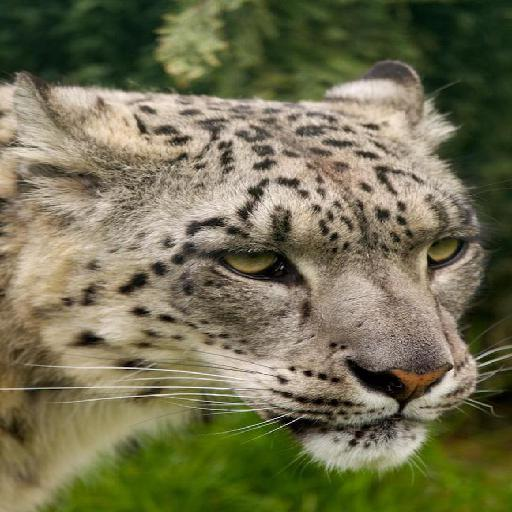

Image index: 2392, similarity: 0.0


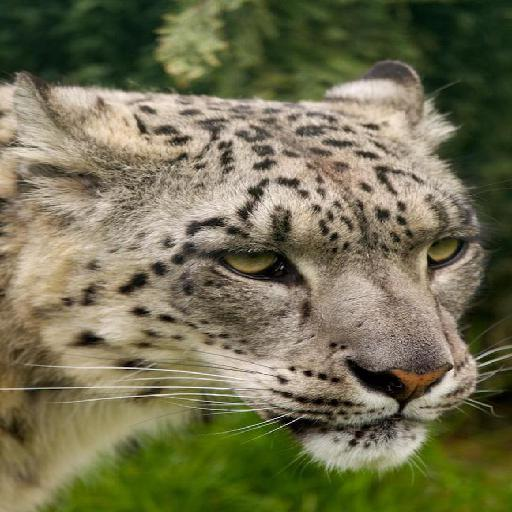

Image index: 2524, similarity: 1.8092478513717651


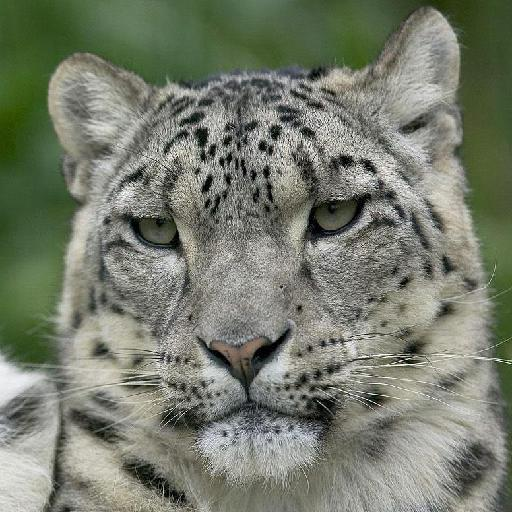

Image index: 1374, similarity: 1.8337445259094238


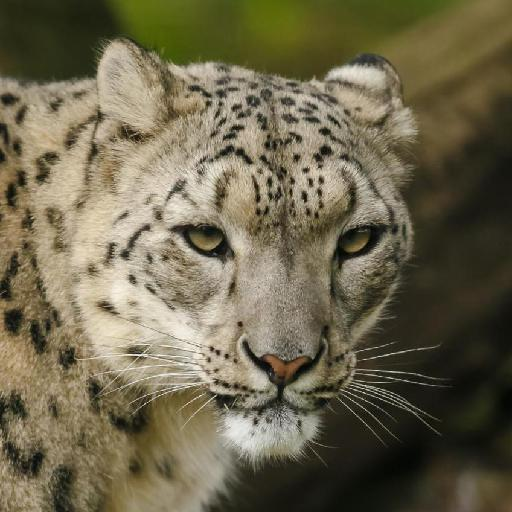

Image index: 1511, similarity: 1.8818727731704712


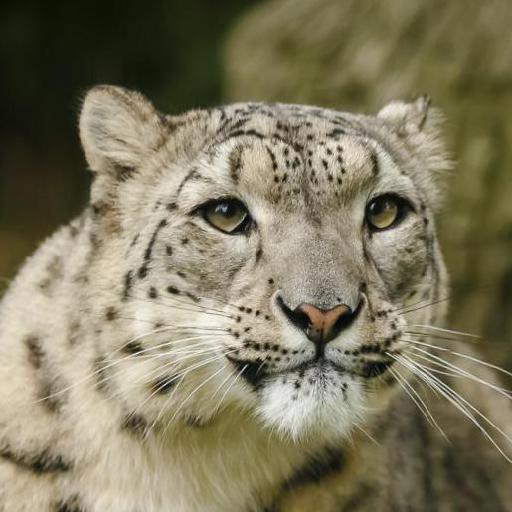

Image index: 513, similarity: 1.8821169137954712


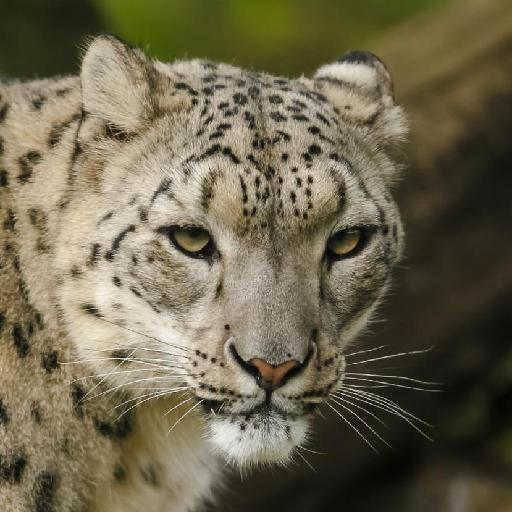

In [2]:
import os
import numpy as np
import faiss
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from transformers import ViTModel, ViTImageProcessor
from PIL import Image as PILImage
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # using gpu of the local pc 
print(f"Using device: {device}")


model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k') # fetching the vit mmodel by google from hugging face. 
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
model.to(device)


def extract_features(image_path):
    image = PILImage.open(image_path) # open the img 
    inputs = processor(images=image, return_tensors="pt").to(device) # loads the images turned into tensors to gpu
    with torch.no_grad():
        outputs = model(**inputs)
    features = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()   # unpacking the features' embedding provided by the model. 
    return features


dataset_dir = Path("/home/abhinav/img_query/dataset") # change the path in your pc 


embeddings = []
image_paths = []
for image_path in dataset_dir.glob('*.jpg'):
    features = extract_features(image_path) # feature extraction of each path 
    embeddings.append(features)
    image_paths.append(str(image_path)) # storing the corresponding img path. 


embeddings_np = np.array(embeddings).astype('float32')
#----converting the embeddings into 
dimension = embeddings_np.shape[1] 
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_np)
#---



faiss.write_index(index, "knn.index")



df = pd.DataFrame({"image_path": image_paths})

query_image_path = "/home/abhinav/img_query/dataset/1.jpg"  # change the query image here.
query_features = extract_features(query_image_path)

# Perform a search
k = 5  # Number of nearest neighbors to return
D, I = index.search(np.expand_dims(query_features, 0), k) # the similarity distance is generated here aswell.
 
print("Query Image:")
display(Image(filename=query_image_path))

for d, i in zip(D[0], I[0]):
    print(f"Image index: {i}, similarity_distance: {d}")
    display(Image(filename=df["image_path"].iloc[i]))

2024-11-06 16:04:59.212142: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-06 16:04:59.292088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730889299.333283    4356 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730889299.344010    4356 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-06 16:04:59.420499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Using device: cuda
Query Image:


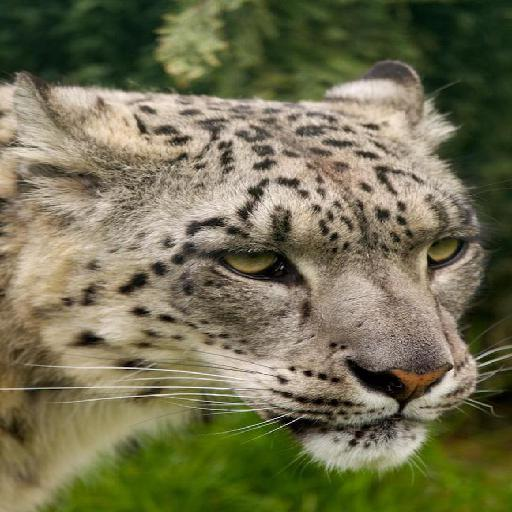

Image index: 2392, similarity: 1.0000


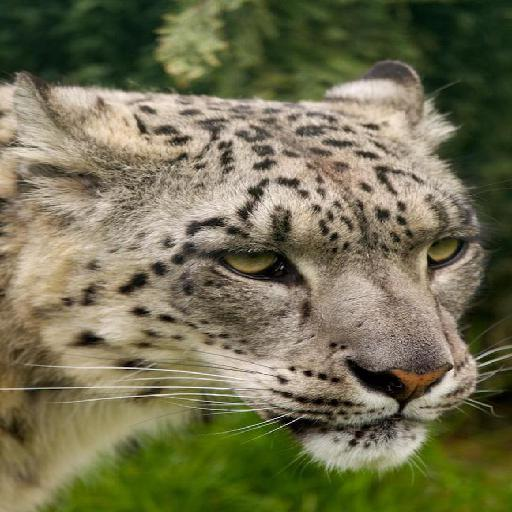

Image index: 2742, similarity: 0.0403


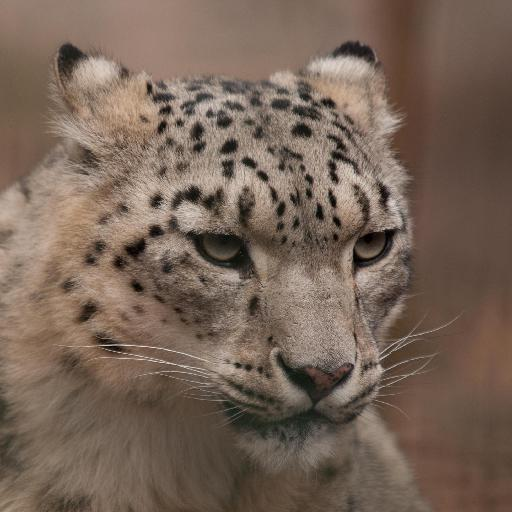

Image index: 1374, similarity: 0.0205


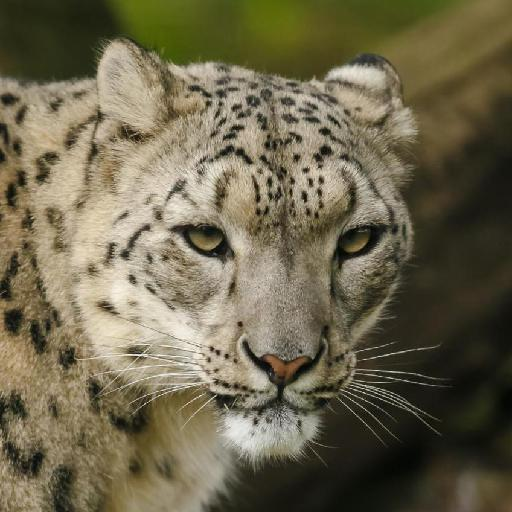

Image index: 1702, similarity: 0.0085


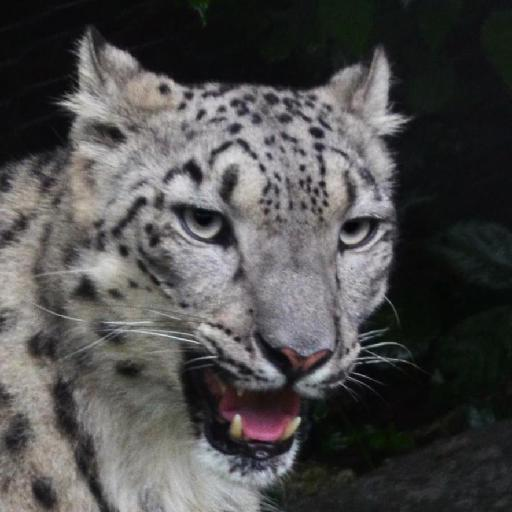

Image index: 513, similarity: 0.0000


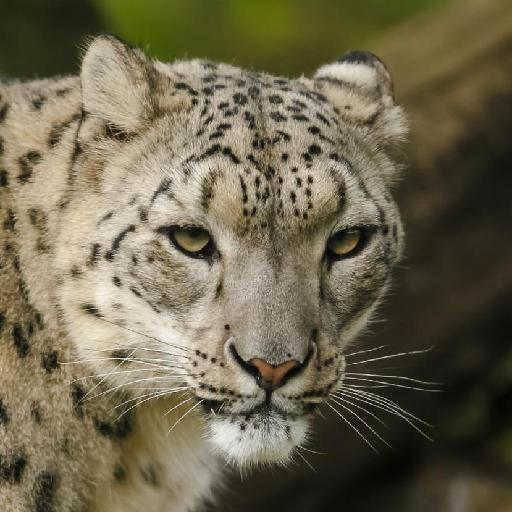

In [1]:
import os
import numpy as np
import faiss
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
import torch
from torchvision import transforms
from PIL import Image as PILImage
from transformers import AutoImageProcessor, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_name = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.to(device)

def extract_features(image_path):
    image = PILImage.open(image_path)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    features = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return features

dataset_dir = Path("/home/abhinav/img_query/dataset")

embeddings = []
image_paths = []
for image_path in dataset_dir.glob('*.jpg'):
    features = extract_features(image_path)
    embeddings.append(features)
    image_paths.append(str(image_path))

embeddings_np = np.array(embeddings).astype('float32')

dimension = embeddings_np.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_np)

faiss.write_index(index, "knn.index")

df = pd.DataFrame({"image_path": image_paths})

query_image_path = "/home/abhinav/img_query/dataset/1.jpg"
query_features = extract_features(query_image_path)

k = 5
D, I = index.search(np.expand_dims(query_features, 0), k)

max_distance = np.max(D)
min_distance = np.min(D)
similarity_scores = 1 - (D - min_distance) / (max_distance - min_distance)

print("Query Image:")
display(Image(filename=query_image_path))

for s, i in zip(similarity_scores[0], I[0]):
    print(f"Image index: {i}, similarity: {s:.4f}")
    display(Image(filename=df["image_path"].iloc[i]))